# WESM Price Prediction - Model 1: Linear Regression

## Setup and Loading

This notebook trains a Vanilla Linear Regression model as the baseline for predicting Luzon GWAP (Generation Weighted Average Price) from WESM market features.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(df.head())

Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00
             datetime       GWAP  energy_demand_mw  energy_supply_mw  \
0 2025-10-29 00:05:00  2258.5866           9504.45           9705.25   
1 2025-10-29 00:10:00  2913.4257           9483.49           9648.89   
2 2025-10-29 00:15:00  2883.5764           9434.35           9627.98   
3 2025-10-29 00:20:00  2888.6233           9417.62           9614.19   
4 2025-10-29 00:25:00  2887.9553           9379.48           9575.17   

   energy_shortage_mw  reserve_demand_mw  reserve_supply_mw  outage_count  \
0             -200.80             1428.0             1428.0           4.0   
1             -165.40             1428.0             1428.0           4.0   
2             -193.63             1428.0             1428.0           4.0   
3             -196.57             1428.0             1428.0           4.0   
4             -195.69             1428.0             1428.0           4.0   

   GWAP_Lag_1  GWAP_La

---

## I. Feature Selection

The target variable is `GWAP`. The following features are used as inputs:

| Feature | Justification |
|---|---|
| `energy_demand_mw` | Higher demand drives up price |
| `energy_supply_mw` | Higher supply brings down price |
| `reserve_demand_mw` | Reserve requirements affect market tightness |
| `reserve_supply_mw` | Reserve availability affects market stability |
| `outage_count` | More outages reduce available capacity, pushing price up |
| `GWAP_Lag_1` | Strong autoregressive signal (price 5 minutes ago) |
| `GWAP_Lag_12` | Intra-hour price memory (1 hour ago) |
| `GWAP_Lag_288` | Same-time-yesterday seasonality (24 hours ago) |
| `hour_sin`, `hour_cos` | Cyclical encoding of intraday price patterns |
| `dow_1` to `dow_6` | Day-of-week effects (weekday vs. weekend demand) |

**Note:** `energy_shortage_mw` is excluded because it is a linear combination of `energy_demand_mw` and `energy_supply_mw` (`shortage = demand - supply`). If we include all three, there will be perfect multicollinearity, which makes linear regression coefficients unreliable.

In [34]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 16
Features: ['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


---

## II. Train / Validation / Test Split

Because this is a time-series dataset, a **chronological split** is used instead of a random split. Shuffling the data would allow the lag features (`GWAP_Lag_1`, `GWAP_Lag_12`, `GWAP_Lag_288`) to reference future GWAP values. That essentially lets the model see the future during training.

In [35]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  20721 rows | 2025-10-29 to 2026-01-08
Val   :   6907 rows | 2026-01-08 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


The dataset spans approximately 4 months (late October 2025 to late February 2026). The split is:
- **Train**: first 60% of rows (~Oct 29 - Jan 8)
- **Validation**: next 20% of rows (~Jan 8 - Feb 1)
- **Test**: final 20% of rows (~Feb 1 - Feb 26)

**Note:** Since Vanilla Linear Regression has no hyperparameters to tune, the validation set is not used for model selection in this notebook. It is evaluated here solely so that we have a consistent evaluation framework with the other models.

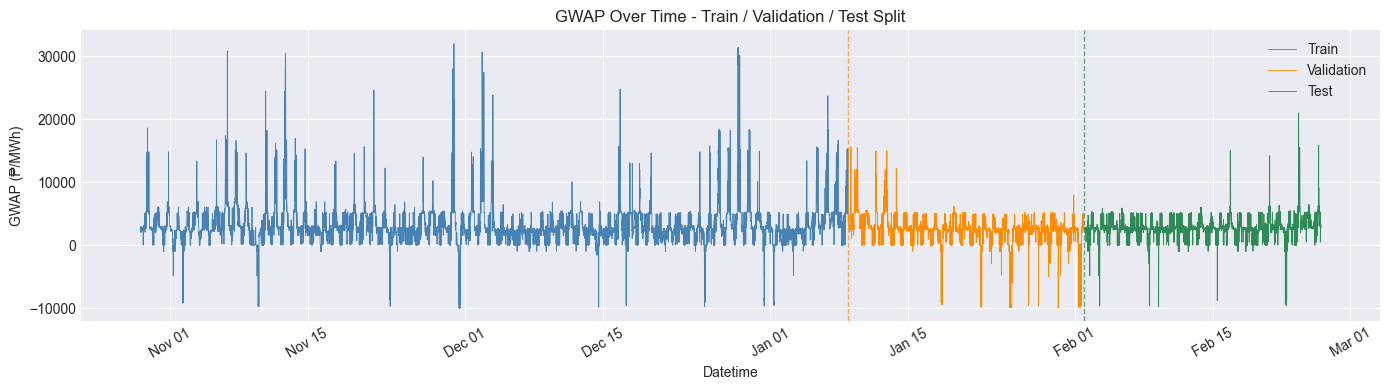

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("GWAP Over Time - Train / Validation / Test Split")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [37]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

---

## III. Feature Scaling

**Standardization** is applied to all features. The features are on very different scales ( `energy_demand_mw` is in the thousands of MW while `hour_sin`/`hour_cos` are between −1 and 1) so without scaling, larger-magnitude features would dominate the coefficients.

The scaler is **fit only on the training set**. The validation and test sets are then transformed using the training set's mean and standard deviation to avoid data leakage.

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Transform val and test using training statistics
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train mean: {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"Train std: {X_train_scaled.std(axis=0).mean():.6f}")

Train mean: -0.000000
Train std: 1.000000


---

## IV. Model Training

Two models are trained:

1. **`lr`** - trained on the training set only. Used to evaluate train and validation performance, and would be used for hyperparameter selection in regularized models.
2. **`lr_final`** - retrained on the combined train + validation set. This is the model used for final test evaluation, following standard protocol: once the selection phase is complete, all non-test data should be used for the final fit.

Both use the ordinary least squares (OLS) analytical solution.

In [39]:
# Model for train/val evaluation (selection phase)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Final model retrained on train + val combined (for test evaluation)
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval        = pd.concat([y_train, y_val])

lr_final = LinearRegression()
lr_final.fit(X_trainval_scaled, y_trainval)

print(f"lr       intercept (train only)  : {lr.intercept_:.4f}")
print(f"lr_final intercept (train + val) : {lr_final.intercept_:.4f}")

lr       intercept (train only)  : 3234.6480
lr_final intercept (train + val) : 3235.1900


---

## V. Evaluation

The model is evaluated across all three splits using:
- **RMSE** (Root Mean Squared Error): main metric; same unit as GWAP (₱/MWh), penalizes large errors more heavily.
- **MAE** (Mean Absolute Error): average absolute error; less sensitive to extreme price spikes.
- **R²** (Coefficient of Determination): proportion of GWAP variance explained by the model.

Train and validation are evaluated using `lr`. The test set is evaluated using `lr_final`.

In [40]:
def evaluate(model, X, y, label):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    print(f"{label:<12} | RMSE: {rmse:>12.4f} | MAE: {mae:>10.4f} | R\u00b2: {r2:>8.4f}")
    return y_pred, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>18} | {'MAE':>14} | {'R\u00b2':>12}")
print("-" * 68)

# lr evaluated on its own training data
y_train_pred, train_rmse, train_mae, train_r2 = evaluate(lr, X_train_scaled, y_train, "Train")

# lr evaluated on validation (unseen to lr)  
y_val_pred, val_rmse, val_mae, val_r2 = evaluate(lr, X_val_scaled, y_val, "Validation")

# lr_final evaluated on its own training data (train+val combined)
y_trainval_pred, trainval_rmse, _, _ = evaluate(lr_final, X_trainval_scaled, y_trainval, "Train+Val")

# lr_final evaluated on test (unseen to lr_final)
y_test_pred, test_rmse, test_mae, test_r2 = evaluate(lr_final, X_test_scaled, y_test, "Test")

Split        |               RMSE |            MAE |           R²
--------------------------------------------------------------------
Train        | RMSE:    1241.3816 | MAE:   576.6604 | R²:   0.8191
Validation   | RMSE:    1043.6622 | MAE:   510.0297 | R²:   0.8160
Train+Val    | RMSE:    1194.6325 | MAE:   560.4642 | R²:   0.8219
Test         | RMSE:     934.4698 | MAE:   459.4758 | R²:   0.6714


Based on the results above, the model performs reasonably well. A test RMSE of ₱934 may sound large but the target variable spans from -₱9,999 to over ₱32,000, which is a range of around ₱42,000.

The test MAE of ₱459 is a bit more representative of typical prediction error since RMSE is more sensitive to outliers and spike events inflate it. (The error analysis in Section VIII also confirms this. RMSE drops to ₱562 for the 75.6% of test intervals in the normal ₱2,000-₱5,000 range.)

The test R² of 0.671 means the model explains about 67% of GWAP variance on the test data, which is a reasonable baseline for a linear model on a highly volatile electricity market.

### Bias-Variance Diagnosis

Following the Tips and Tricks lecture, each model is compared against its own training performance. `lr` is compared against its train RMSE for the val gap and `lr_final` is compared against its train+val RMSE for the test gap. This ensures an apples-to-apples comparison where each gap measures how much worse the model does on unseen data relative to what it was fit on.

In [41]:
gap_val  = val_rmse - train_rmse        # lr on unseen val vs lr on train
gap_test = test_rmse - trainval_rmse    # lr_final on unseen test vs lr_final on train+val

print(f"Val  - Train gap     : {gap_val:.4f}  ({gap_val / train_rmse * 100:.1f}% of train RMSE)")
print(f"Test - Train+Val gap : {gap_test:.4f}  ({gap_test / trainval_rmse * 100:.1f}% of train+val RMSE)")

Val  - Train gap     : -197.7194  (-15.9% of train RMSE)
Test - Train+Val gap : -260.1627  (-21.8% of train+val RMSE)


**Val - Train (`lr`):** Validation RMSE (1,044) is lower than train RMSE (1,241) with a gap of -15.9%. The validation period (Jan 8 - Feb 1) contained less volatile GWAP intervals than the October-January training period. No overfitting.

**Test - Train+Val (`lr_final`):** Test RMSE (934) is also lower than Train+Val RMSE (1,195), meaning the model's average error on February data is actually smaller than on its training data. This likely means February's typical intervals were less volatile and easier to predict on average.

---

## VI. Visualizations

### Actual vs. Predicted - Test Set (Time Series)

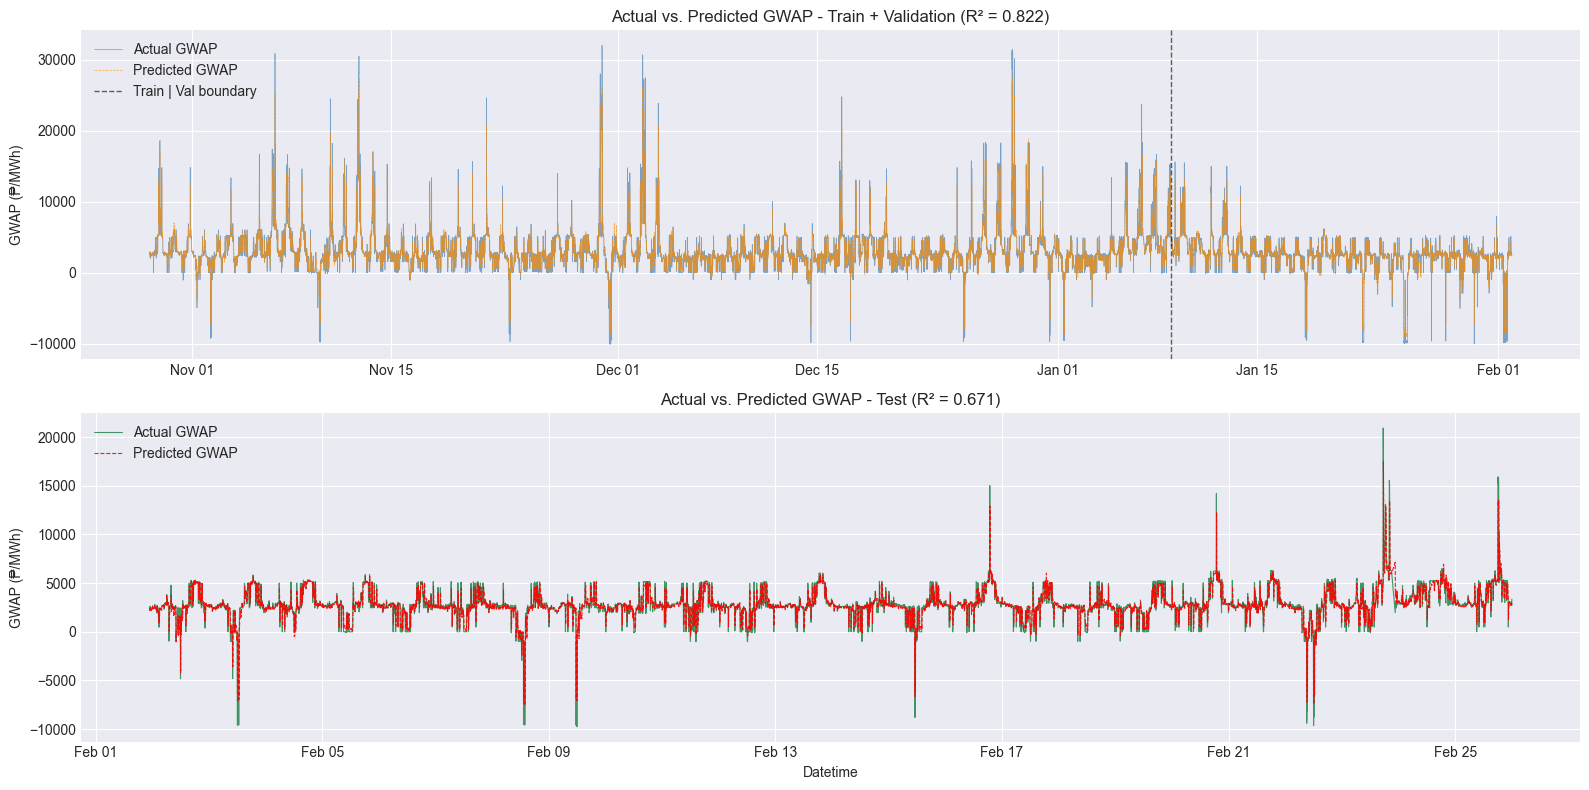

Train+Val GWAP std : 2830.47
Test GWAP std      : 1630.35


In [42]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Train+Val
axes[0].plot(train_df["datetime"].values, y_train.values, color="steelblue", linewidth=0.5, alpha=0.7, label="Actual GWAP")
axes[0].plot(val_df["datetime"].values,   y_val.values,   color="steelblue", linewidth=0.5, alpha=0.7)
axes[0].plot(train_df["datetime"].values, lr_final.predict(X_train_scaled), color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--", label="Predicted GWAP")
axes[0].plot(val_df["datetime"].values,   lr_final.predict(X_val_scaled),   color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--")
axes[0].axvline(val_df["datetime"].min(), color="black", linestyle="--", linewidth=1, alpha=0.6, label="Train | Val boundary")
axes[0].set_title("Actual vs. Predicted GWAP - Train + Validation (R² = 0.822)")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].legend(loc="upper left")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Test
axes[1].plot(test_df["datetime"].values, y_test.values, color="seagreen",  linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[1].plot(test_df["datetime"].values, y_test_pred,   color="red",       linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[1].set_title("Actual vs. Predicted GWAP - Test (R² = 0.671)")
axes[1].set_ylabel("GWAP (₱/MWh)")
axes[1].set_xlabel("Datetime")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

print(f"Train+Val GWAP std : {y_trainval.std():.2f}")
print(f"Test GWAP std      : {y_test.std():.2f}")

In both periods, the model predicts the general trend and typical price range well. The predictions closely follow actual values during stable and normal-priced intervals. However, the model visibly undershoots during sudden upward price spikes and also underestimates negative dips.

The R² drop from 0.822 to 0.671 is not because the model performs worse in February since RMSE is actually lower in the test period (934 vs 1,195). February's GWAP is significantly less spread out (std = 1,630 vs 2,830), so even similarly-sized errors account for a larger share of the smaller spread.

### Actual vs. Predicted - Scatter Plot

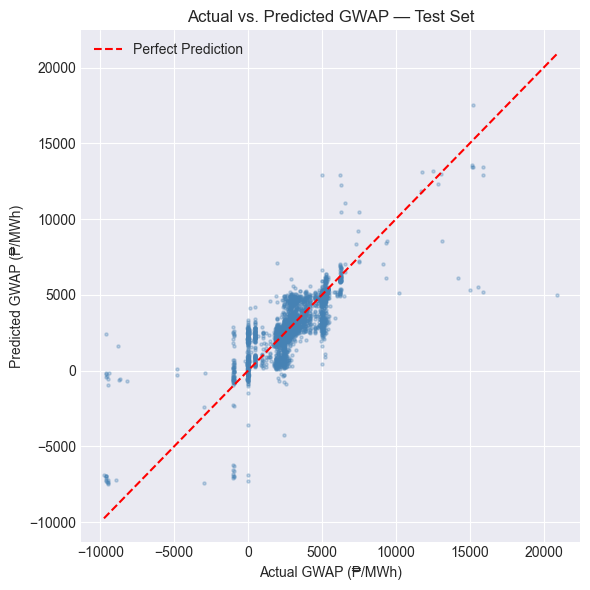

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_test_pred, alpha=0.3, s=5, color="steelblue")

# Perfect prediction line
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted GWAP — Test Set")
ax.set_xlabel("Actual GWAP (₱/MWh)")
ax.set_ylabel("Predicted GWAP (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

The dense cluster around ₱2,000-₱5,000 sits close to the diagonal line, which confirms good fit in the normal price range. Deviations are most visible at the extremes: at high actual GWAP values the model underpredicts (points fall below the diagonal) and at negative GWAP values the model also struggles to reach the same depth (points fall above the diagonal).

### Residual Plot

Residuals here are just the difference between actual and predicted GWAP (actual - predicted).

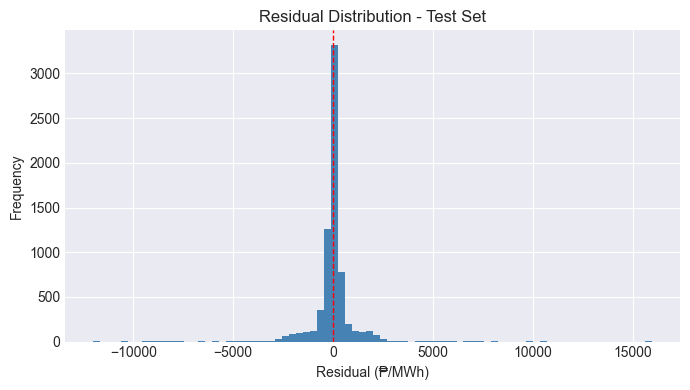

Mean Residual : -7.1931  (close to 0 = unbiased)
Std Residual  : 934.4421
Max Residual  : 15962.6729
Min Residual  : -12001.9491


In [44]:
residuals_test = y_test.values - y_test_pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(residuals_test, bins=80, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution - Test Set")
ax.set_xlabel("Residual (₱/MWh)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals_test.mean():.4f}  (close to 0 = unbiased)")
print(f"Std Residual  : {residuals_test.std():.4f}")
print(f"Max Residual  : {residuals_test.max():.4f}")
print(f"Min Residual  : {residuals_test.min():.4f}")

The residual distribution shows that most predictions are very close to actual values but a significant number of extreme errors exist on both ends. This is consistent with electricity price data where the bulk of intervals are well-behaved but rare spike events produce large. This is a symptom of underfitting at the extremes as the model is too simple to represent the relationship between features and GWAP during market stress conditions.

---

## VII. Feature Coefficients

Since all features were standardized before training, the coefficients are on the same scale and can be directly compared. A larger absolute coefficient means that feature has a stronger influence on the predicted GWAP. Coefficients are taken from `lr_final` since that is the model used for test evaluation.

In [45]:
coef_df = pd.DataFrame({
    "Feature"    : FEATURE_COLS,
    "Coefficient": lr_final.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))

          Feature  Coefficient
       GWAP_Lag_1  2259.988106
      GWAP_Lag_12   281.988666
     GWAP_Lag_288   260.816050
 energy_demand_mw   168.794265
 energy_supply_mw  -119.902029
            dow_6   -76.540952
            dow_3   -60.547077
            dow_5   -57.374907
reserve_supply_mw    52.240786
            dow_2   -50.370049
            dow_4   -41.183377
            dow_1   -30.915110
reserve_demand_mw   -17.454022
         hour_sin   -13.335064
         hour_cos    -2.544933
     outage_count     2.306113


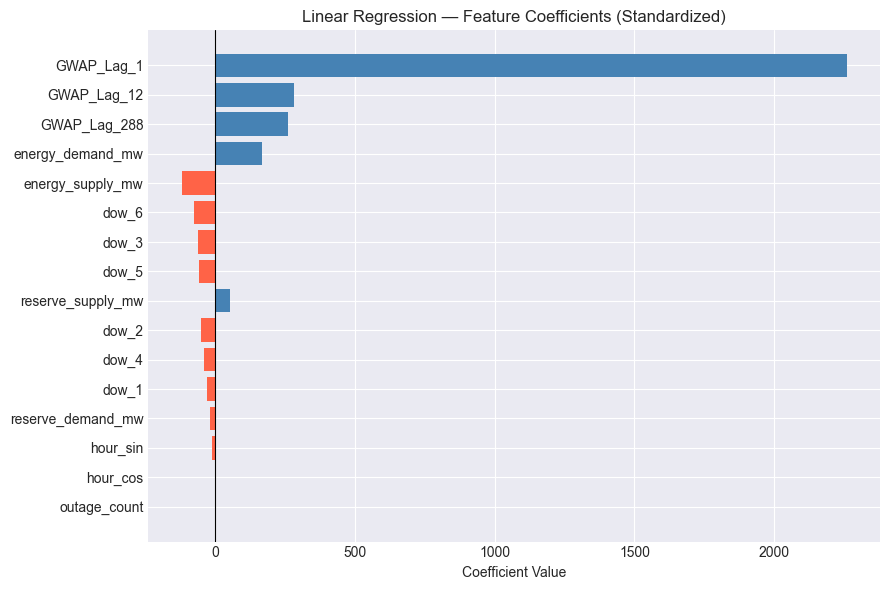

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["steelblue" if c >= 0 else "tomato" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title("Linear Regression — Feature Coefficients (Standardized)")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

GWAP_Lag_1 dominates at 2,260, which means the price 5 minutes ago is the strongest predictor of the current price. The next two highest features are also lag features (GWAP_Lag_12 at 282 and GWAP_Lag_288 at 261), confirming that GWAP is strongly autoregressive.

Energy demand (+169) and supply (-120) have the expected signs because demand pushes price up, supply pushes it down. The coefficients should be interpreted carefully though, since both features tend to move together and the model may not be able to cleanly separate their individual contributions. Similarly, reserve_demand_mw has a negative coefficient (-17.5) which is counterintuitive but this may be a result of its correlation with reserve_supply_mw rather than an actual negative relationship with price.

(Both demand and supply are kept because they represent economically distinct concepts.)

---

## VIII. Error Analysis

To quantify where errors are concentrated, we segment the test set by GWAP range and compute RMSE and MAE per segment.

In [47]:
error_df = test_df[["datetime", "GWAP"]].copy()
error_df["predicted"] = y_test_pred
error_df["residual"]  = error_df["GWAP"] - error_df["predicted"]
error_df["abs_error"] = error_df["residual"].abs()

# Segment by GWAP range
bins   = [-10000, 0, 2000, 5000, 10000, 35000]
labels = ["Negative", "0-2k", "2k-5k", "5k-10k", ">10k"]
error_df["gwap_segment"] = pd.cut(error_df["GWAP"], bins=bins, labels=labels)

segment_summary = error_df.groupby("gwap_segment", observed=True).agg(
    count      = ("GWAP", "count"),
    mean_gwap  = ("GWAP", "mean"),
    rmse       = ("residual", lambda x: np.sqrt((x**2).mean())),
    mae        = ("abs_error", "mean")
).reset_index()

print(segment_summary.to_string(index=False))

gwap_segment  count    mean_gwap        rmse         mae
    Negative    459  -695.253988 2208.886686 1308.144410
        0-2k    411  1084.738367 1220.638104  914.756695
       2k-5k   5219  2806.565112  562.212687  318.002658
      5k-10k    800  5302.908570 1014.637240  572.293644
        >10k     18 14405.645722 6264.010822 4428.058035


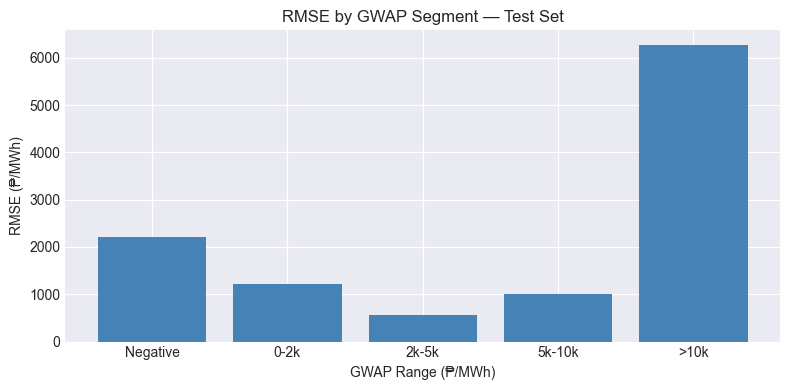

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(segment_summary["gwap_segment"].astype(str), segment_summary["rmse"], color="steelblue")
ax.set_title("RMSE by GWAP Segment — Test Set")
ax.set_xlabel("GWAP Range (₱/MWh)")
ax.set_ylabel("RMSE (₱/MWh)")
plt.tight_layout()
plt.show()

The segmented error analysis confirms what we had expected:

- **Normal range (₱2,000-₱5,000)** accounts for 5,219 of 6,907 test intervals (~75.6%) and achieves an RMSE of only ₱562. Which means the model performs well here.
- **₱5,000-₱10,000 range** sees RMSE jump to ₱1,015, as the model begins to underpredict higher prices.
- **Negative GWAP** (459 intervals, ~6.6% of test) has an RMSE of ₱2,209. These over-generation events are abrupt and driven by non-linear strategic bidding behavior that a linear model cannot replicate.
- **Above ₱10,000** (only 18 intervals) has an RMSE of ₱6,264 (over 11x the normal-range error). These rare scarcity spikes are the hardest prediction target in the dataset.